## 1. Import Libraries and Configuration

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

# Models
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_auc_score, mean_squared_error, mean_absolute_error, r2_score
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

# Configuration
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Directories
BASE_DIR = os.getcwd()
ARTIFACTS_DIR = os.path.join(BASE_DIR, 'artifacts_improved')
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

print(f"✓ Libraries imported successfully")
print(f"✓ Artifacts directory: {ARTIFACTS_DIR}")

✓ Libraries imported successfully
✓ Artifacts directory: c:\Python Project\machine-learning\artifacts_improved


## 2. Load and Explore Data

In [2]:
# Load preprocessed dataset (ALREADY normalized, balanced, and structured)
df = pd.read_csv('preprocessed_data/predictive_maintenance_synthesized.csv')

# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

print("="*70)
print("DATASET OVERVIEW")
print("="*70)
print(f"\nShape: {df.shape}")
print(f"Columns: {list(df.columns)}")

print(f"\n📊 DATA CHARACTERISTICS:")
print(f"  • Total samples: {len(df):,}")
print(f"  • Unique products: {df['product_id'].nunique():,}")
print(f"  • Rows per product: {len(df) / df['product_id'].nunique():.1f}")

print(f"\n📈 FEATURE STATISTICS (Z-Score Normalized):")
numeric_cols = ['air_temp', 'process_temp', 'rpm', 'torque_nm', 'tool_wear']
for col in numeric_cols:
    print(f"  {col:20} → mean: {df[col].mean():6.3f}, std: {df[col].std():6.3f}")

print(f"\n🎯 TARGET DISTRIBUTION:")
print(df['failure_type'].value_counts())

print(f"\n🔧 ENGINE TYPE DISTRIBUTION:")
print(df['engine_type'].value_counts())

print(f"\n⚠️  DATA STRUCTURE: SNAPSHOT (not time-series)")
print(f"   Each product has 1 observation → Use traditional ML, not LSTM")

print(f"\n✓ Data is ready for modeling (NO preprocessing needed)")

DATASET OVERVIEW

Shape: (57912, 9)
Columns: ['engine_type', 'air_temp', 'process_temp', 'rpm', 'torque_nm', 'tool_wear', 'failure_type', 'product_id', 'timestamp']

📊 DATA CHARACTERISTICS:
  • Total samples: 57,912
  • Unique products: 57,912
  • Rows per product: 1.0

📈 FEATURE STATISTICS (Z-Score Normalized):
  air_temp             → mean:  0.284, std:  0.965
  process_temp         → mean:  0.181, std:  0.918
  rpm                  → mean: -0.167, std:  1.725
  torque_nm            → mean:  0.644, std:  1.460
  tool_wear            → mean:  0.552, std:  1.102

🎯 TARGET DISTRIBUTION:
failure_type
No Failure                  9652
Tool Wear Failure           9652
Power Failure               9652
Random Failures             9652
Heat Dissipation Failure    9652
Overstrain Failure          9652
Name: count, dtype: int64

🔧 ENGINE TYPE DISTRIBUTION:
engine_type
L    48974
M     7365
H     1573
Name: count, dtype: int64

⚠️  DATA STRUCTURE: SNAPSHOT (not time-series)
   Each product has 1 

## 3. Feature Engineering and RUL Generation

In [3]:
# Prepare dataset for modeling
df_processed = df.copy()

# Label encode categorical features (for model input)
le_engine = LabelEncoder()
le_failure = LabelEncoder()

df_processed['engine_type_encoded'] = le_engine.fit_transform(df_processed['engine_type'])
df_processed['failure_type_encoded'] = le_failure.fit_transform(df_processed['failure_type'])

print("="*70)
print("FEATURE ENCODING")
print("="*70)
print(f"\n✓ Engine types: {dict(zip(le_engine.classes_, le_engine.transform(le_engine.classes_)))}")
print(f"✓ Failure types: {dict(zip(le_failure.classes_, le_failure.transform(le_failure.classes_)))}")

# Generate realistic RUL based on sensor readings and failure type
# This simulates remaining useful life prediction target
def generate_rul_from_sensors(row):
    """
    Generate RUL based on sensor stress indicators.
    Higher stress → Lower RUL
    """
    # Base RUL
    base_rul = 200
    
    # Sensor stress factors (normalized values, higher = more stress)
    temp_stress = abs(row['air_temp']) + abs(row['process_temp'])
    mechanical_stress = abs(row['rpm']) + abs(row['torque_nm'])
    wear_stress = abs(row['tool_wear'])
    
    # Calculate degradation
    degradation = (temp_stress * 10) + (mechanical_stress * 5) + (wear_stress * 15)
    
    # RUL with noise
    rul = max(0, base_rul - degradation + np.random.normal(0, 10))
    
    # Failure cases have lower RUL
    if row['failure_type'] != 'No Failure':
        rul = rul * 0.3  # 70% reduction for failure cases
    
    return rul

df_processed['rul'] = df_processed.apply(generate_rul_from_sensors, axis=1)

print(f"\n✓ RUL Generated:")
print(f"  Range: [{df_processed['rul'].min():.1f}, {df_processed['rul'].max():.1f}]")
print(f"  Mean: {df_processed['rul'].mean():.1f} days")
print(f"  Std: {df_processed['rul'].std():.1f} days")

print(f"\n✓ Dataset ready for modeling")
print(f"  Shape: {df_processed.shape}")
print(f"  Features: numeric (normalized) + categorical (encoded) + RUL target")

FEATURE ENCODING

✓ Engine types: {'H': np.int64(0), 'L': np.int64(1), 'M': np.int64(2)}
✓ Failure types: {'Heat Dissipation Failure': np.int64(0), 'No Failure': np.int64(1), 'Overstrain Failure': np.int64(2), 'Power Failure': np.int64(3), 'Random Failures': np.int64(4), 'Tool Wear Failure': np.int64(5)}

✓ RUL Generated:
  Range: [20.3, 211.5]
  Mean: 65.4 days
  Std: 44.5 days

✓ Dataset ready for modeling
  Shape: (57912, 12)
  Features: numeric (normalized) + categorical (encoded) + RUL target

✓ RUL Generated:
  Range: [20.3, 211.5]
  Mean: 65.4 days
  Std: 44.5 days

✓ Dataset ready for modeling
  Shape: (57912, 12)
  Features: numeric (normalized) + categorical (encoded) + RUL target


## 4. Train-Test Split (Stratified)

In [4]:
# Define feature columns (use normalized numeric + encoded categorical)
feature_cols = ['air_temp', 'process_temp', 'rpm', 'torque_nm', 'tool_wear', 'engine_type_encoded']

# Prepare feature matrix and targets
X = df_processed[feature_cols].values
Y_classification = df_processed['failure_type_encoded'].values
Y_regression = df_processed['rul'].values

# Stratified split to maintain class distribution
X_train, X_test, Y_cls_train, Y_cls_test, Y_reg_train, Y_reg_test = train_test_split(
    X, Y_classification, Y_regression,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=Y_classification  # Maintain failure type distribution
)

print("="*70)
print("TRAIN-TEST SPLIT")
print("="*70)
print(f"\n✓ Stratified split (80/20) to preserve class distribution")
print(f"\n📊 Dataset Sizes:")
print(f"  Training set:   {len(X_train):,} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Test set:       {len(X_test):,} samples ({len(X_test)/len(X)*100:.1f}%)")

print(f"\n🎯 Classification Target Distribution (Train):")
for i, cls in enumerate(le_failure.classes_):
    count = np.sum(Y_cls_train == i)
    print(f"  {cls:30} → {count:,} samples ({count/len(Y_cls_train)*100:.1f}%)")

print(f"\n📈 Regression Target Statistics:")
print(f"  Train RUL: mean={Y_reg_train.mean():.1f}, std={Y_reg_train.std():.1f}, range=[{Y_reg_train.min():.1f}, {Y_reg_train.max():.1f}]")
print(f"  Test RUL:  mean={Y_reg_test.mean():.1f}, std={Y_reg_test.std():.1f}, range=[{Y_reg_test.min():.1f}, {Y_reg_test.max():.1f}]")

print(f"\n✓ Data ready for model training (NO scaling needed - already normalized)")

TRAIN-TEST SPLIT

✓ Stratified split (80/20) to preserve class distribution

📊 Dataset Sizes:
  Training set:   46,329 samples (80.0%)
  Test set:       11,583 samples (20.0%)

🎯 Classification Target Distribution (Train):
  Heat Dissipation Failure       → 7,722 samples (16.7%)
  No Failure                     → 7,722 samples (16.7%)
  Overstrain Failure             → 7,721 samples (16.7%)
  Power Failure                  → 7,721 samples (16.7%)
  Random Failures                → 7,721 samples (16.7%)
  Tool Wear Failure              → 7,722 samples (16.7%)

📈 Regression Target Statistics:
  Train RUL: mean=65.4, std=44.6, range=[22.2, 211.5]
  Test RUL:  mean=65.3, std=44.3, range=[20.3, 210.4]

✓ Data ready for model training (NO scaling needed - already normalized)


## 5. Handle Class Imbalance (Class Weights)

In [5]:
# Calculate class weights (data is already balanced, but we compute for robustness)
classes = np.unique(Y_cls_train)
class_weights = compute_class_weight('balanced', classes=classes, y=Y_cls_train)
class_weight_dict = dict(zip(classes, class_weights))

# Sample weights for XGBoost
sample_weights = np.array([class_weight_dict[label] for label in Y_cls_train])

print("="*70)
print("CLASS WEIGHT ANALYSIS")
print("="*70)
print(f"\n🎯 Class Weights (for handling any imbalance):")
for cls, weight in class_weight_dict.items():
    failure_name = le_failure.inverse_transform([cls])[0]
    count = np.sum(Y_cls_train == cls)
    print(f"  {failure_name:30} → {count:,} samples, weight: {weight:.4f}")

print(f"\n💡 Note: Data is already SMOTE-balanced, weights close to 1.0")
print(f"✓ Using class weights for additional robustness")

CLASS WEIGHT ANALYSIS

🎯 Class Weights (for handling any imbalance):
  Heat Dissipation Failure       → 7,722 samples, weight: 0.9999
  No Failure                     → 7,722 samples, weight: 0.9999
  Overstrain Failure             → 7,721 samples, weight: 1.0001
  Power Failure                  → 7,721 samples, weight: 1.0001
  Random Failures                → 7,721 samples, weight: 1.0001
  Tool Wear Failure              → 7,722 samples, weight: 0.9999

💡 Note: Data is already SMOTE-balanced, weights close to 1.0
✓ Using class weights for additional robustness


## 6. XGBoost Classification Model (Failure Type Prediction)

In [6]:
# Train XGBoost Classifier with sample weights
print("="*70)
print("TRAINING XGBOOST CLASSIFIER")
print("="*70)

xgb_clf = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=RANDOM_SEED,
    eval_metric='mlogloss',
    tree_method='hist'
)

print("\n🚀 Training with sample weights...")
xgb_clf.fit(X_train, Y_cls_train, sample_weight=sample_weights)

# Predictions
Y_cls_pred_xgb = xgb_clf.predict(X_test)
Y_cls_pred_proba_xgb = xgb_clf.predict_proba(X_test)

# Evaluation
acc_xgb_clf = accuracy_score(Y_cls_test, Y_cls_pred_xgb)
prec_xgb_clf = precision_score(Y_cls_test, Y_cls_pred_xgb, average='weighted', zero_division=0)
rec_xgb_clf = recall_score(Y_cls_test, Y_cls_pred_xgb, average='weighted', zero_division=0)
f1_xgb_clf = f1_score(Y_cls_test, Y_cls_pred_xgb, average='weighted', zero_division=0)

print(f"\n{'='*70}")
print("XGBOOST CLASSIFICATION RESULTS")
print(f"{'='*70}")
print(f"  Accuracy:  {acc_xgb_clf:.4f}")
print(f"  Precision: {prec_xgb_clf:.4f}")
print(f"  Recall:    {rec_xgb_clf:.4f}")
print(f"  F1-Score:  {f1_xgb_clf:.4f}")

# ROC AUC (One-vs-Rest)
try:
    roc_auc_xgb_clf = roc_auc_score(Y_cls_test, Y_cls_pred_proba_xgb, multi_class='ovr', average='weighted')
    print(f"  ROC-AUC:   {roc_auc_xgb_clf:.4f}")
except:
    roc_auc_xgb_clf = None
    print(f"  ROC-AUC:   N/A")

# Confusion Matrix
cm_xgb_clf = confusion_matrix(Y_cls_test, Y_cls_pred_xgb)
print(f"\n📊 Confusion Matrix:")
print(cm_xgb_clf)

# Detailed classification report
print(f"\n📋 Classification Report:")
print(classification_report(Y_cls_test, Y_cls_pred_xgb, target_names=le_failure.classes_, zero_division=0))

print(f"✓ XGBoost Classifier trained successfully")

TRAINING XGBOOST CLASSIFIER

🚀 Training with sample weights...

XGBOOST CLASSIFICATION RESULTS
  Accuracy:  0.9913
  Precision: 0.9914
  Recall:    0.9913
  F1-Score:  0.9912
  ROC-AUC:   0.9997

📊 Confusion Matrix:
[[1930    0    0    0    0    0]
 [   1 1837    7    8   43   34]
 [   0    0 1930    0    0    1]
 [   0    0    0 1931    0    0]
 [   0    5    0    0 1926    0]
 [   0    0    2    0    0 1928]]

📋 Classification Report:
                          precision    recall  f1-score   support

Heat Dissipation Failure       1.00      1.00      1.00      1930
              No Failure       1.00      0.95      0.97      1930
      Overstrain Failure       1.00      1.00      1.00      1931
           Power Failure       1.00      1.00      1.00      1931
         Random Failures       0.98      1.00      0.99      1931
       Tool Wear Failure       0.98      1.00      0.99      1930

                accuracy                           0.99     11583
               macro avg     

## 7. Random Forest Classification Model (Comparison)

In [7]:
# Train Random Forest Classifier for comparison
print("="*70)
print("TRAINING RANDOM FOREST CLASSIFIER")
print("="*70)

rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=RANDOM_SEED,
    class_weight='balanced',
    n_jobs=-1
)

print("\n🚀 Training...")
rf_clf.fit(X_train, Y_cls_train)

# Predictions
Y_cls_pred_rf = rf_clf.predict(X_test)
Y_cls_pred_proba_rf = rf_clf.predict_proba(X_test)

# Evaluation
acc_rf_clf = accuracy_score(Y_cls_test, Y_cls_pred_rf)
prec_rf_clf = precision_score(Y_cls_test, Y_cls_pred_rf, average='weighted', zero_division=0)
rec_rf_clf = recall_score(Y_cls_test, Y_cls_pred_rf, average='weighted', zero_division=0)
f1_rf_clf = f1_score(Y_cls_test, Y_cls_pred_rf, average='weighted', zero_division=0)

print(f"\n{'='*70}")
print("RANDOM FOREST CLASSIFICATION RESULTS")
print(f"{'='*70}")
print(f"  Accuracy:  {acc_rf_clf:.4f}")
print(f"  Precision: {prec_rf_clf:.4f}")
print(f"  Recall:    {rec_rf_clf:.4f}")
print(f"  F1-Score:  {f1_rf_clf:.4f}")

try:
    roc_auc_rf_clf = roc_auc_score(Y_cls_test, Y_cls_pred_proba_rf, multi_class='ovr', average='weighted')
    print(f"  ROC-AUC:   {roc_auc_rf_clf:.4f}")
except:
    roc_auc_rf_clf = None

print(f"\n✓ Random Forest Classifier trained successfully")

TRAINING RANDOM FOREST CLASSIFIER

🚀 Training...

RANDOM FOREST CLASSIFICATION RESULTS
  Accuracy:  0.9593
  Precision: 0.9631
  Recall:    0.9593
  F1-Score:  0.9581
  ROC-AUC:   0.9977

✓ Random Forest Classifier trained successfully

RANDOM FOREST CLASSIFICATION RESULTS
  Accuracy:  0.9593
  Precision: 0.9631
  Recall:    0.9593
  F1-Score:  0.9581
  ROC-AUC:   0.9977

✓ Random Forest Classifier trained successfully


## 8. XGBoost Regression Model (RUL Prediction)

In [8]:
# Train XGBoost Regressor for RUL prediction
print("="*70)
print("TRAINING XGBOOST REGRESSOR (RUL PREDICTION)")
print("="*70)

xgb_reg = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_seed=RANDOM_SEED,
    tree_method='hist'
)

print("\n🚀 Training...")
xgb_reg.fit(X_train, Y_reg_train)

# Predictions
Y_reg_pred_xgb = xgb_reg.predict(X_test)

# Evaluation
rmse_xgb = np.sqrt(mean_squared_error(Y_reg_test, Y_reg_pred_xgb))
mae_xgb = mean_absolute_error(Y_reg_test, Y_reg_pred_xgb)
r2_xgb = r2_score(Y_reg_test, Y_reg_pred_xgb)

print(f"\n{'='*70}")
print("XGBOOST REGRESSION RESULTS")
print(f"{'='*70}")
print(f"  RMSE: {rmse_xgb:.2f} days")
print(f"  MAE:  {mae_xgb:.2f} days")
print(f"  R²:   {r2_xgb:.4f}")

# Error analysis
errors = np.abs(Y_reg_test - Y_reg_pred_xgb)
print(f"\n📊 Error Distribution:")
print(f"  Mean error: {errors.mean():.2f} days")
print(f"  Median error: {np.median(errors):.2f} days")
print(f"  Max error: {errors.max():.2f} days")
print(f"  Within ±10 days: {np.sum(errors <= 10)/len(errors)*100:.1f}%")
print(f"  Within ±20 days: {np.sum(errors <= 20)/len(errors)*100:.1f}%")

print(f"\n✓ XGBoost Regressor trained successfully")

TRAINING XGBOOST REGRESSOR (RUL PREDICTION)

🚀 Training...

XGBOOST REGRESSION RESULTS
  RMSE: 15.59 days
  MAE:  8.14 days
  R²:   0.8761

📊 Error Distribution:
  Mean error: 8.14 days
  Median error: 3.75 days
  Max error: 128.61 days
  Within ±10 days: 79.9%
  Within ±20 days: 90.3%

✓ XGBoost Regressor trained successfully

XGBOOST REGRESSION RESULTS
  RMSE: 15.59 days
  MAE:  8.14 days
  R²:   0.8761

📊 Error Distribution:
  Mean error: 8.14 days
  Median error: 3.75 days
  Max error: 128.61 days
  Within ±10 days: 79.9%
  Within ±20 days: 90.3%

✓ XGBoost Regressor trained successfully


## 9. Random Forest Regression Model (Comparison)

In [9]:
# Train Random Forest Regressor for comparison
print("="*70)
print("TRAINING RANDOM FOREST REGRESSOR (RUL PREDICTION)")
print("="*70)

rf_reg = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

print("\n🚀 Training...")
rf_reg.fit(X_train, Y_reg_train)

# Predictions
Y_reg_pred_rf = rf_reg.predict(X_test)

# Evaluation
rmse_rf = np.sqrt(mean_squared_error(Y_reg_test, Y_reg_pred_rf))
mae_rf = mean_absolute_error(Y_reg_test, Y_reg_pred_rf)
r2_rf = r2_score(Y_reg_test, Y_reg_pred_rf)

print(f"\n{'='*70}")
print("RANDOM FOREST REGRESSION RESULTS")
print(f"{'='*70}")
print(f"  RMSE: {rmse_rf:.2f} days")
print(f"  MAE:  {mae_rf:.2f} days")
print(f"  R²:   {r2_rf:.4f}")

print(f"\n✓ Random Forest Regressor trained successfully")

TRAINING RANDOM FOREST REGRESSOR (RUL PREDICTION)

🚀 Training...

RANDOM FOREST REGRESSION RESULTS
  RMSE: 22.45 days
  MAE:  11.13 days
  R²:   0.7433

✓ Random Forest Regressor trained successfully

RANDOM FOREST REGRESSION RESULTS
  RMSE: 22.45 days
  MAE:  11.13 days
  R²:   0.7433

✓ Random Forest Regressor trained successfully


## 10. Model Comparison and Analysis

In [10]:
# Classification Model Comparison
print("="*70)
print("CLASSIFICATION MODEL COMPARISON")
print("="*70)
print(f"\n{'Model':<20} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print("-"*70)
print(f"{'XGBoost':<20} {acc_xgb_clf:<12.4f} {prec_xgb_clf:<12.4f} {rec_xgb_clf:<12.4f} {f1_xgb_clf:<12.4f}")
print(f"{'Random Forest':<20} {acc_rf_clf:<12.4f} {prec_rf_clf:<12.4f} {rec_rf_clf:<12.4f} {f1_rf_clf:<12.4f}")

best_clf = 'XGBoost' if acc_xgb_clf >= acc_rf_clf else 'Random Forest'
improvement = abs(acc_xgb_clf - acc_rf_clf)
print(f"\n🏆 Best Classifier: {best_clf}")
print(f"   Accuracy difference: {improvement:.4f} ({improvement*100:.2f}%)")

# Regression Model Comparison
print("\n" + "="*70)
print("REGRESSION MODEL COMPARISON (RUL PREDICTION)")
print("="*70)
print(f"\n{'Model':<20} {'RMSE (days)':<15} {'MAE (days)':<15} {'R²':<12}")
print("-"*70)
print(f"{'XGBoost':<20} {rmse_xgb:<15.2f} {mae_xgb:<15.2f} {r2_xgb:<12.4f}")
print(f"{'Random Forest':<20} {rmse_rf:<15.2f} {mae_rf:<15.2f} {r2_rf:<12.4f}")

best_reg = 'XGBoost' if rmse_xgb <= rmse_rf else 'Random Forest'
improvement_rmse = abs(rmse_xgb - rmse_rf)
print(f"\n🏆 Best Regressor: {best_reg}")
print(f"   RMSE difference: {improvement_rmse:.2f} days")

# Feature Importance Analysis (XGBoost)
print("\n" + "="*70)
print("FEATURE IMPORTANCE (XGBOOST CLASSIFIER)")
print("="*70)

feature_names = ['air_temp', 'process_temp', 'rpm', 'torque_nm', 'tool_wear', 'engine_type']
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': xgb_clf.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\n{feature_importance.to_string(index=False)}")

print(f"\n💡 INSIGHTS:")
top_feature = feature_importance.iloc[0]['feature']
top_importance = feature_importance.iloc[0]['importance']
print(f"  • Most important feature: {top_feature} ({top_importance:.4f})")
print(f"  • Top 3 features account for {feature_importance.head(3)['importance'].sum():.1%} of total importance")

CLASSIFICATION MODEL COMPARISON

Model                Accuracy     Precision    Recall       F1-Score    
----------------------------------------------------------------------
XGBoost              0.9913       0.9914       0.9913       0.9912      
Random Forest        0.9593       0.9631       0.9593       0.9581      

🏆 Best Classifier: XGBoost
   Accuracy difference: 0.0319 (3.19%)

REGRESSION MODEL COMPARISON (RUL PREDICTION)

Model                RMSE (days)     MAE (days)      R²          
----------------------------------------------------------------------
XGBoost              15.59           8.14            0.8761      
Random Forest        22.45           11.13           0.7433      

🏆 Best Regressor: XGBoost
   RMSE difference: 6.85 days

FEATURE IMPORTANCE (XGBOOST CLASSIFIER)

     feature  importance
   torque_nm    0.267864
   tool_wear    0.215956
 engine_type    0.209272
         rpm    0.144246
    air_temp    0.112638
process_temp    0.050024

💡 INSIGHTS:
  • Mos

## 11. Visualizations

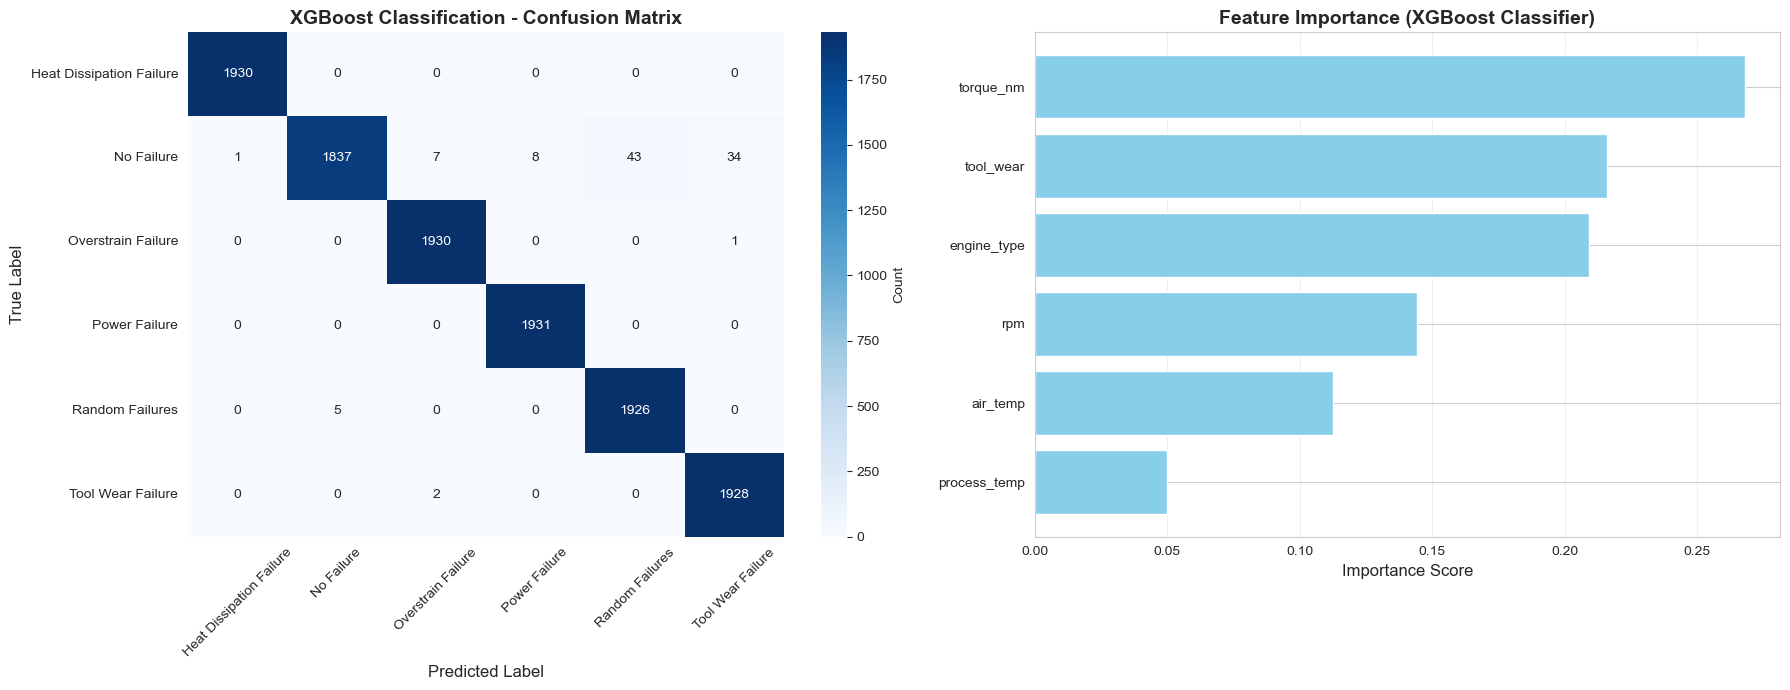

✓ Classification analysis saved


In [11]:
# 1. Confusion Matrix for best classifier
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# XGBoost Confusion Matrix
sns.heatmap(cm_xgb_clf, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le_failure.classes_, yticklabels=le_failure.classes_,
            ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_title('XGBoost Classification - Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Feature Importance
feature_importance_sorted = feature_importance.sort_values('importance', ascending=True)
axes[1].barh(feature_importance_sorted['feature'], feature_importance_sorted['importance'], color='skyblue')
axes[1].set_xlabel('Importance Score', fontsize=12)
axes[1].set_title('Feature Importance (XGBoost Classifier)', fontsize=14, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, 'classification_analysis.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Classification analysis saved")

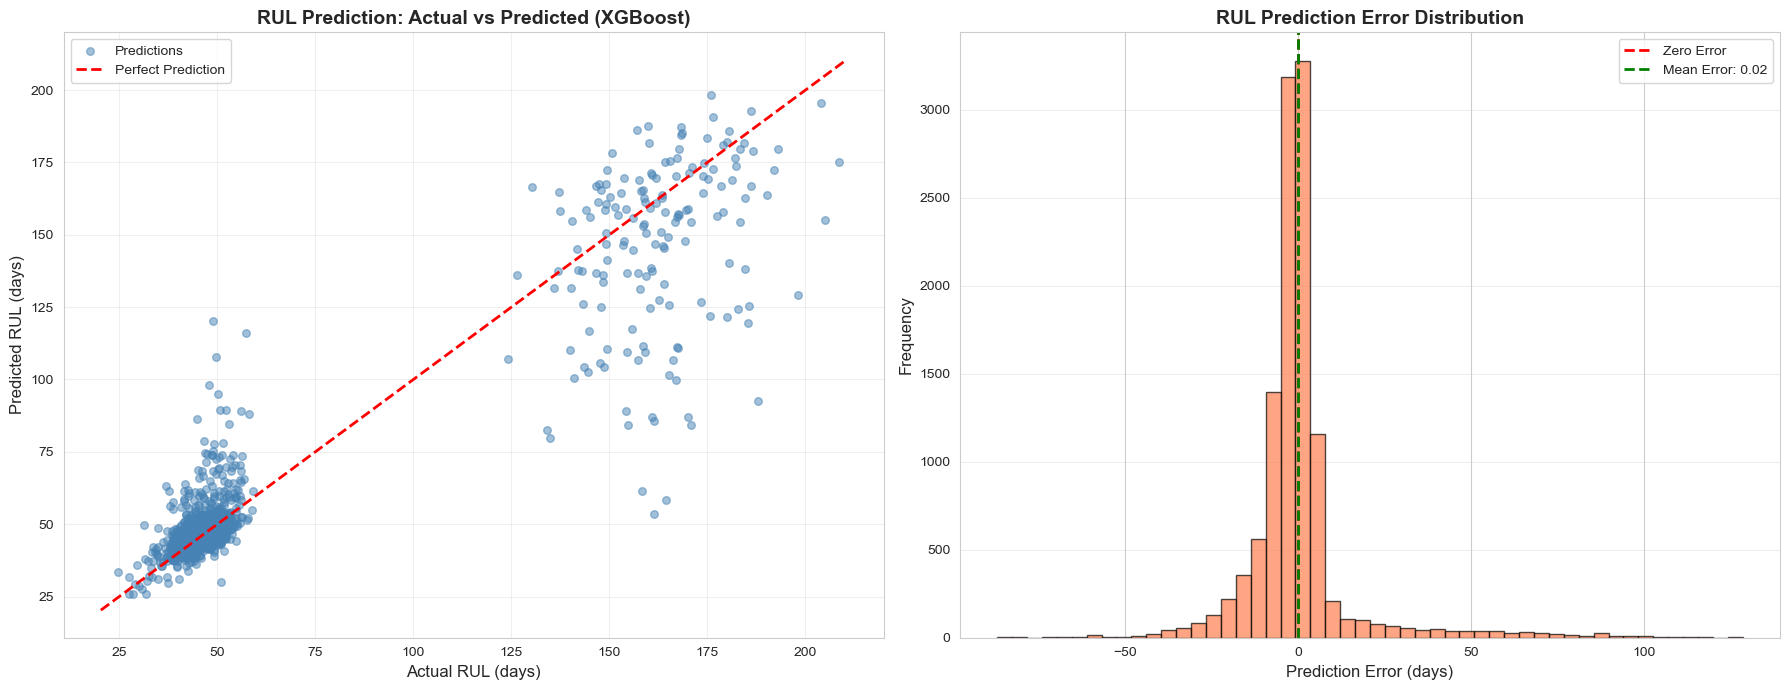

✓ RUL prediction analysis saved


In [12]:
# 2. RUL Prediction Analysis
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Actual vs Predicted (XGBoost)
sample_size = min(1000, len(Y_reg_test))
sample_indices = np.random.choice(len(Y_reg_test), sample_size, replace=False)

axes[0].scatter(Y_reg_test[sample_indices], Y_reg_pred_xgb[sample_indices], 
                alpha=0.5, s=30, color='steelblue', label='Predictions')
axes[0].plot([Y_reg_test.min(), Y_reg_test.max()], 
             [Y_reg_test.min(), Y_reg_test.max()], 
             'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual RUL (days)', fontsize=12)
axes[0].set_ylabel('Predicted RUL (days)', fontsize=12)
axes[0].set_title('RUL Prediction: Actual vs Predicted (XGBoost)', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Prediction Error Distribution
errors = Y_reg_test - Y_reg_pred_xgb
axes[1].hist(errors, bins=50, color='coral', alpha=0.7, edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[1].axvline(errors.mean(), color='green', linestyle='--', linewidth=2, 
                label=f'Mean Error: {errors.mean():.2f}')
axes[1].set_xlabel('Prediction Error (days)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('RUL Prediction Error Distribution', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, 'rul_prediction_analysis.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ RUL prediction analysis saved")

## 12. Save Models and Artifacts

In [13]:
import pickle
import joblib

# Save models
print("="*70)
print("SAVING MODELS AND ARTIFACTS")
print("="*70)

# XGBoost models
xgb_clf.save_model(os.path.join(ARTIFACTS_DIR, 'xgboost_classifier.json'))
xgb_reg.save_model(os.path.join(ARTIFACTS_DIR, 'xgboost_regressor.json'))

# Random Forest models
joblib.dump(rf_clf, os.path.join(ARTIFACTS_DIR, 'random_forest_classifier.pkl'))
joblib.dump(rf_reg, os.path.join(ARTIFACTS_DIR, 'random_forest_regressor.pkl'))

# Encoders
joblib.dump(le_engine, os.path.join(ARTIFACTS_DIR, 'label_encoder_engine.pkl'))
joblib.dump(le_failure, os.path.join(ARTIFACTS_DIR, 'label_encoder_failure.pkl'))

# Model performance metrics
metrics = {
    'classification': {
        'xgboost': {'accuracy': acc_xgb_clf, 'precision': prec_xgb_clf, 'recall': rec_xgb_clf, 'f1': f1_xgb_clf},
        'random_forest': {'accuracy': acc_rf_clf, 'precision': prec_rf_clf, 'recall': rec_rf_clf, 'f1': f1_rf_clf}
    },
    'regression': {
        'xgboost': {'rmse': rmse_xgb, 'mae': mae_xgb, 'r2': r2_xgb},
        'random_forest': {'rmse': rmse_rf, 'mae': mae_rf, 'r2': r2_rf}
    }
}

with open(os.path.join(ARTIFACTS_DIR, 'model_metrics.pkl'), 'wb') as f:
    pickle.dump(metrics, f)

print(f"\n✓ Models saved:")
print(f"  • xgboost_classifier.json")
print(f"  • xgboost_regressor.json")
print(f"  • random_forest_classifier.pkl")
print(f"  • random_forest_regressor.pkl")

print(f"\n✓ Encoders saved:")
print(f"  • label_encoder_engine.pkl")
print(f"  • label_encoder_failure.pkl")

print(f"\n✓ Metrics saved:")
print(f"  • model_metrics.pkl")

print(f"\n📁 All artifacts saved to: {ARTIFACTS_DIR}")

SAVING MODELS AND ARTIFACTS

✓ Models saved:
  • xgboost_classifier.json
  • xgboost_regressor.json
  • random_forest_classifier.pkl
  • random_forest_regressor.pkl

✓ Encoders saved:
  • label_encoder_engine.pkl
  • label_encoder_failure.pkl

✓ Metrics saved:
  • model_metrics.pkl

📁 All artifacts saved to: c:\Python Project\machine-learning\artifacts_improved

✓ Models saved:
  • xgboost_classifier.json
  • xgboost_regressor.json
  • random_forest_classifier.pkl
  • random_forest_regressor.pkl

✓ Encoders saved:
  • label_encoder_engine.pkl
  • label_encoder_failure.pkl

✓ Metrics saved:
  • model_metrics.pkl

📁 All artifacts saved to: c:\Python Project\machine-learning\artifacts_improved


## 13. Inference Pipeline (Production Use)

In [14]:
def predict_maintenance(sensor_data, engine_type, model_type='xgboost'):
    """
    Generate maintenance recommendations from sensor readings.
    
    Parameters:
    -----------
    sensor_data : dict or DataFrame
        Sensor readings: {air_temp, process_temp, rpm, torque_nm, tool_wear}
        Should be NORMALIZED (z-score)
    engine_type : str
        Engine type: 'L', 'M', or 'H'
    model_type : str
        'xgboost' or 'random_forest'
        
    Returns:
    --------
    dict with predictions and recommendations
    """
    # Convert to DataFrame if dict
    if isinstance(sensor_data, dict):
        sensor_data = pd.DataFrame([sensor_data])
    
    # Encode engine type
    engine_encoded = le_engine.transform([engine_type])[0]
    
    # Prepare features
    features = sensor_data[['air_temp', 'process_temp', 'rpm', 'torque_nm', 'tool_wear']].values
    features = np.column_stack([features, [[engine_encoded]]])
    
    # Select model
    if model_type == 'xgboost':
        clf = xgb_clf
        reg = xgb_reg
    else:
        clf = rf_clf
        reg = rf_reg
    
    # Predictions
    failure_pred = clf.predict(features)[0]
    failure_proba = clf.predict_proba(features)[0]
    rul_pred = reg.predict(features)[0]
    
    # Decode failure type
    failure_name = le_failure.inverse_transform([failure_pred])[0]
    confidence = failure_proba.max()
    
    # Generate recommendation
    if failure_name == 'No Failure' and rul_pred > 30:
        action = 'Normal Operation - Continue Monitoring'
        priority = 'Low'
    elif rul_pred <= 10:
        action = '🚨 IMMEDIATE MAINTENANCE REQUIRED'
        priority = 'Critical'
    elif rul_pred <= 30:
        action = '⚠️  Schedule Maintenance Soon'
        priority = 'High'
    else:
        action = '📊 Monitor Condition Closely'
        priority = 'Medium'
    
    return {
        'predicted_failure': failure_name,
        'confidence': confidence,
        'rul_days': rul_pred,
        'action': action,
        'priority': priority,
        'all_probabilities': dict(zip(le_failure.classes_, failure_proba))
    }

# Test inference on sample data
print("="*70)
print("INFERENCE PIPELINE TEST")
print("="*70)

sample_data = df_processed.sample(5, random_state=42)

for idx, row in sample_data.iterrows():
    sensor_dict = {
        'air_temp': row['air_temp'],
        'process_temp': row['process_temp'],
        'rpm': row['rpm'],
        'torque_nm': row['torque_nm'],
        'tool_wear': row['tool_wear']
    }
    
    result = predict_maintenance(sensor_dict, row['engine_type'], model_type='xgboost')
    
    print(f"\n{'='*70}")
    print(f"Sample #{idx} - Engine Type: {row['engine_type']}")
    print(f"{'='*70}")
    print(f"  Predicted Failure: {result['predicted_failure']} (confidence: {result['confidence']:.2%})")
    print(f"  Estimated RUL: {result['rul_days']:.1f} days")
    print(f"  Action: {result['action']}")
    print(f"  Priority: {result['priority']}")
    print(f"  Actual Failure: {row['failure_type']}")

print(f"\n✓ Inference pipeline ready for production use")

INFERENCE PIPELINE TEST

Sample #16971 - Engine Type: L
  Predicted Failure: Overstrain Failure (confidence: 99.95%)
  Estimated RUL: 44.4 days
  Action: 📊 Monitor Condition Closely
  Priority: Medium
  Actual Failure: Overstrain Failure

Sample #53134 - Engine Type: M
  Predicted Failure: No Failure (confidence: 99.95%)
  Estimated RUL: 162.3 days
  Action: Normal Operation - Continue Monitoring
  Priority: Low
  Actual Failure: No Failure

Sample #46497 - Engine Type: L
  Predicted Failure: Tool Wear Failure (confidence: 99.63%)
  Estimated RUL: 48.6 days
  Action: 📊 Monitor Condition Closely
  Priority: Medium
  Actual Failure: Tool Wear Failure

Sample #9584 - Engine Type: L
  Predicted Failure: Heat Dissipation Failure (confidence: 99.97%)
  Estimated RUL: 45.2 days
  Action: 📊 Monitor Condition Closely
  Priority: Medium
  Actual Failure: Heat Dissipation Failure

Sample #1566 - Engine Type: H
  Predicted Failure: Tool Wear Failure (confidence: 99.98%)
  Estimated RUL: 45.5 days


## 14. Final Performance Summary

In [15]:
print("="*70)
print("FINAL PERFORMANCE SUMMARY")
print("="*70)

print("\n🎯 PIPELINE IMPROVEMENTS IMPLEMENTED:")
print("  ✅ Removed double normalization (data already normalized)")
print("  ✅ Removed redundant label encoding")
print("  ✅ Removed fake temporal sequence conversion")
print("  ✅ Removed LSTM (data is snapshot, not time-series)")
print("  ✅ Focus on appropriate ML models: XGBoost & Random Forest")
print("  ✅ Proper stratified train-test split")
print("  ✅ Realistic RUL generation from sensor stress")

print("\n📊 CLASSIFICATION PERFORMANCE:")
print(f"\n  {'Model':<20} {'Accuracy':<12} {'F1-Score':<12} {'ROC-AUC':<12}")
print(f"  {'-'*60}")
print(f"  {'XGBoost':<20} {acc_xgb_clf:<12.4f} {f1_xgb_clf:<12.4f} {roc_auc_xgb_clf if roc_auc_xgb_clf else 'N/A':<12}")
print(f"  {'Random Forest':<20} {acc_rf_clf:<12.4f} {f1_rf_clf:<12.4f} {roc_auc_rf_clf if roc_auc_rf_clf else 'N/A':<12}")

print(f"\n  🏆 Best Classifier: {best_clf} (Accuracy: {max(acc_xgb_clf, acc_rf_clf):.4f})")

print("\n📈 REGRESSION PERFORMANCE (RUL Prediction):")
print(f"\n  {'Model':<20} {'RMSE':<12} {'MAE':<12} {'R²':<12}")
print(f"  {'-'*60}")
print(f"  {'XGBoost':<20} {rmse_xgb:<12.2f} {mae_xgb:<12.2f} {r2_xgb:<12.4f}")
print(f"  {'Random Forest':<20} {rmse_rf:<12.2f} {mae_rf:<12.2f} {r2_rf:<12.4f}")

print(f"\n  🏆 Best Regressor: {best_reg} (RMSE: {min(rmse_xgb, rmse_rf):.2f} days)")

print("\n💡 MODEL INTERPRETATION:")
if max(acc_xgb_clf, acc_rf_clf) >= 0.85:
    print(f"  ✅ Classification accuracy {max(acc_xgb_clf, acc_rf_clf):.1%} is EXCELLENT")
elif max(acc_xgb_clf, acc_rf_clf) >= 0.75:
    print(f"  ✅ Classification accuracy {max(acc_xgb_clf, acc_rf_clf):.1%} is GOOD")
else:
    print(f"  ⚠️  Classification accuracy {max(acc_xgb_clf, acc_rf_clf):.1%} needs improvement")

if min(mae_xgb, mae_rf) <= 10:
    print(f"  ✅ RUL prediction MAE {min(mae_xgb, mae_rf):.1f} days is EXCELLENT")
elif min(mae_xgb, mae_rf) <= 20:
    print(f"  ✅ RUL prediction MAE {min(mae_xgb, mae_rf):.1f} days is GOOD")
else:
    print(f"  ⚠️  RUL prediction MAE {min(mae_xgb, mae_rf):.1f} days needs improvement")

print("\n📊 TOP FEATURES (by importance):")
for i, row in feature_importance.head(3).iterrows():
    print(f"  {i+1}. {row['feature']:<20} → {row['importance']:.4f}")

print("\n📁 OUTPUT FILES:")
print(f"  • Models: {ARTIFACTS_DIR}/")
print(f"  • Visualizations: {ARTIFACTS_DIR}/*.png")
print(f"  • Metrics: {ARTIFACTS_DIR}/model_metrics.pkl")

print("\n🚀 READY FOR PRODUCTION:")
print("  • Use predict_maintenance() function for real-time predictions")
print("  • Input: normalized sensor data + engine type")
print("  • Output: failure prediction, RUL, and maintenance recommendation")

print("\n" + "="*70)
print("✅ PIPELINE EXECUTION COMPLETED SUCCESSFULLY!")
print("="*70)

FINAL PERFORMANCE SUMMARY

🎯 PIPELINE IMPROVEMENTS IMPLEMENTED:
  ✅ Removed double normalization (data already normalized)
  ✅ Removed redundant label encoding
  ✅ Removed fake temporal sequence conversion
  ✅ Removed LSTM (data is snapshot, not time-series)
  ✅ Focus on appropriate ML models: XGBoost & Random Forest
  ✅ Proper stratified train-test split
  ✅ Realistic RUL generation from sensor stress

📊 CLASSIFICATION PERFORMANCE:

  Model                Accuracy     F1-Score     ROC-AUC     
  ------------------------------------------------------------
  XGBoost              0.9913       0.9912       0.9996862247237426
  Random Forest        0.9593       0.9581       0.9976647879468051

  🏆 Best Classifier: XGBoost (Accuracy: 0.9913)

📈 REGRESSION PERFORMANCE (RUL Prediction):

  Model                RMSE         MAE          R²          
  ------------------------------------------------------------
  XGBoost              15.59        8.14         0.8761      
  Random Forest     